In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from nnsight import LanguageModel, util

def _find_delimiter_token_index(tokenizer, text, delimiter=","):
    """Tokenizer-agnostic delimiter lookup using character offsets."""
    char_idx = text.find(delimiter)
    if char_idx == -1:
        raise ValueError(f"Delimiter '{delimiter}' not found in text.")

    encoded = tokenizer(
        text,
        return_offsets_mapping=True,
        add_special_tokens=True,
    )
    offsets = encoded.get("offset_mapping")
    if offsets is None:
        raise ValueError("Tokenizer did not return offset mapping.")

    for tok_idx, (start, end) in enumerate(offsets):
        # Skip special tokens that often map to (0, 0)
        if start == end:
            continue
        if start <= char_idx < end:
            return tok_idx

    raise ValueError(f"Could not map delimiter '{delimiter}' to token index.")


/home/40455223@eeecs.qub.ac.uk/idiom_comp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
path = "head_accum_llama3b_gpu.npz"
# load the npz file
data = np.load(path)
# print the keys
print(data.keys())

# print the first key
print(data['total_combinations'])


KeysView(NpzFile 'head_accum_llama3b_gpu.npz' with keys: accumulated_results, total_combinations)
178


In [9]:

import json
import numpy as np
import torch

path = "head_accum_llama3b_gpu.npz"
data = np.load(path)

acc = torch.from_numpy(data["accumulated_results"]).float()   # shape: [layers, heads]
n = int(data["total_combinations"])

avg = acc / n
n_layers, n_heads = avg.shape
def top_heads(k):
    vals, idxs = torch.topk(avg.flatten(), k)
    out = []
    for i in idxs.tolist():
        layer = i // n_heads
        head = i % n_heads
        out.append([layer, head])  # save as [layer, head]
    return out

for k in [34, 67, 168]:
    out = top_heads(k)
    with open(f"top_{k}_heads_llama3b_from_accumulator.json", "w") as f:
        json.dump(out, f, indent=2)
    print(f"\nTop {k} heads:")
    print(out)


Top 34 heads:
[[9, 3], [2, 22], [27, 6], [2, 7], [9, 15], [6, 9], [14, 18], [1, 5], [18, 6], [27, 1], [10, 12], [0, 4], [25, 20], [9, 18], [5, 0], [22, 16], [17, 8], [19, 7], [8, 9], [6, 23], [2, 8], [23, 15], [1, 15], [7, 8], [8, 12], [3, 22], [3, 16], [6, 11], [15, 0], [0, 20], [2, 23], [8, 3], [27, 9], [8, 18]]

Top 67 heads:
[[9, 3], [2, 22], [27, 6], [2, 7], [9, 15], [6, 9], [14, 18], [1, 5], [18, 6], [27, 1], [10, 12], [0, 4], [25, 20], [9, 18], [5, 0], [22, 16], [17, 8], [19, 7], [8, 9], [6, 23], [2, 8], [23, 15], [1, 15], [7, 8], [8, 12], [3, 22], [3, 16], [6, 11], [15, 0], [0, 20], [2, 23], [8, 3], [27, 9], [8, 18], [14, 20], [16, 9], [27, 12], [5, 21], [7, 7], [15, 4], [14, 11], [24, 12], [7, 13], [11, 6], [16, 15], [11, 19], [10, 9], [19, 12], [16, 18], [16, 7], [4, 21], [27, 4], [4, 20], [3, 0], [2, 15], [9, 8], [11, 9], [10, 0], [16, 10], [13, 0], [3, 8], [10, 10], [14, 9], [27, 3], [25, 22], [11, 7], [11, 18]]

Top 168 heads:
[[9, 3], [2, 22], [27, 6], [2, 7], [9, 15], [

In [3]:
path = "residual_accum_llama3b.npz"
# load the npz file
data = np.load(path)
# print the keys
print(data.keys())
total_results = data["total_results"]
counts = data["counts"]


KeysView(NpzFile 'residual_accum_llama3b.npz' with keys: total_results, counts)


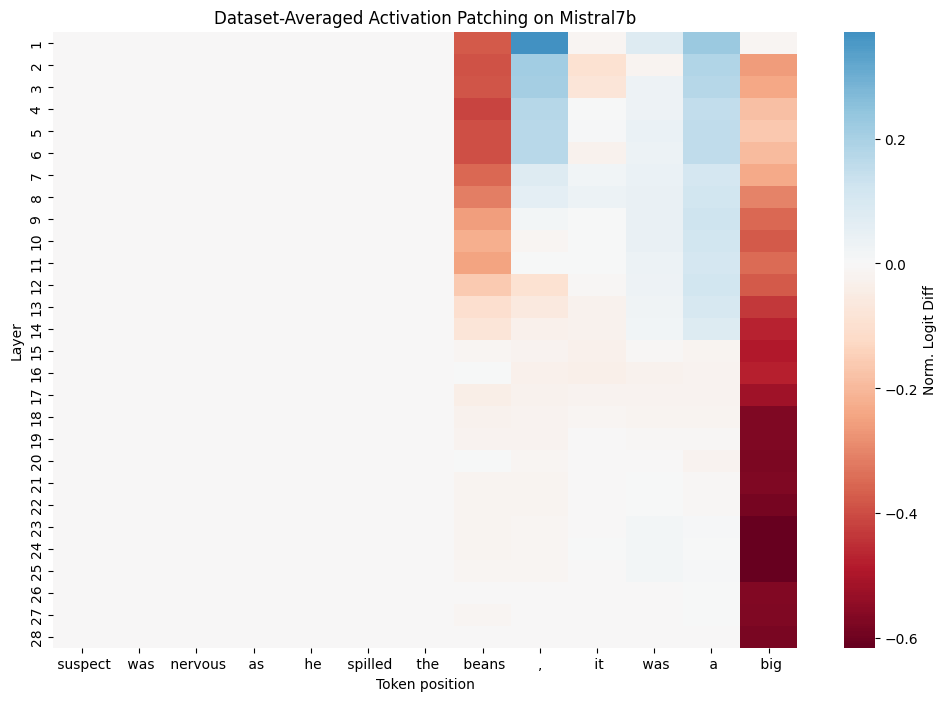

In [ ]:


model = LanguageModel("tiiuae/Falcon3-7B-Base", device_map=device_map, token = access_token)
N_LAYERS = 28
avg_results = np.divide(total_results, counts, out=np.zeros_like(total_results), where=counts!=0)
# Use first idiom's first pair for labels
prompt_idiom = "The suspect was nervous as he spilled the beans, it was a big"
        
idiom_tokens = model.tokenizer(prompt_idiom, return_tensors="pt")["input_ids"][0]
try:
    and_token_idx = _find_delimiter_token_index(model.tokenizer, prompt_idiom, delimiter=",")
    
except ValueError:
    print("Error finding delimiter token index")


label_start = max(0, and_token_idx - 8)
label_end = min(len(idiom_tokens), and_token_idx + 5)
labels = [model.tokenizer.decode(token) for token in idiom_tokens[label_start:label_end]]
# Calculate the absolute maximum to make the scale symmetric
y_labels = list(range(1, N_LAYERS + 1))
plt.figure(figsize=(12, 8))
sns.heatmap(
            avg_results,
            xticklabels=labels,
            yticklabels=y_labels,
            cmap="RdBu",
            cbar_kws={'label': 'Norm. Logit Diff'},
            center=0
        )
plt.xlabel("Token position")
plt.ylabel("Layer")
plt.title(f"Dataset-Averaged Activation Patching on Mistral7b")
# plt.savefig(f"averaged_patching_results_mistral7b.png")
# plt.savefig(f"averaged_patching_results_mistral7b.eps")
plt.gca() # Often helpful to have Layer 0 at the bottom
plt.show()

In [12]:
import json
dataset = json.load(open(f"extended_dataset.json"))
device_map="auto"

print(f"Device map: {device_map}")
model = LanguageModel("tiiuae/Falcon3-7B-Base", device_map=device_map, token = access_token)
N_LAYERS = len(model.model.layers)
N_HEADS = 24
D_MODEL = 3072
D_HEADS = D_MODEL // N_HEADS

Device map: auto


In [15]:
processed_idioms = 0
clean_diff = []
corrupt_diff = []
for idiom_idx, idiom_entry in enumerate(dataset):
        
        processed_idioms += 1
        idiom_id = idiom_entry["id"]
        pairs = idiom_entry["pairs"]
        for pair_idx, pair in enumerate(pairs):
            
            prompt_idiom = pair["prompt_idiom"]
            prompt_literal = pair["prompt_literal"]
            idiom_answers = pair["idiom_answers"]
            literal_answers = pair["literal_answers"]
          

            # tokens
            idiom_tokens = model.tokenizer(prompt_idiom, return_tensors="pt")["input_ids"][0]
            literal_tokens = model.tokenizer(prompt_literal, return_tensors="pt")["input_ids"][0]
            print(len(idiom_tokens), len(literal_tokens))
            min_token_len = min(len(idiom_tokens), len(literal_tokens))
            print(min_token_len)

            # Find delimiter token position in a tokenizer-agnostic way
            try:
                and_token_idx = _find_delimiter_token_index(model.tokenizer, prompt_literal, delimiter=",")
                print(f"comma token idx {and_token_idx}")
            except (RuntimeError, ValueError, IndexError):
                print(f"Skipping idiom={idiom_id}, pair_idx={pair_idx}: comma delimiter not found.")
                continue


            n_answers =3
            for answer_idx in range(n_answers):
                correct_answer = idiom_answers[answer_idx]
                incorrect_answer = literal_answers[answer_idx]
                
                correct_token = model.tokenizer.encode(correct_answer)[0]
                incorrect_token = model.tokenizer.encode(incorrect_answer)[0]
                
                correct_answer_idx = correct_token
                incorrect_answer_idx = incorrect_token

            
            
                # clean/corrupt baseline run (single pass)
                with model.trace() as tracer:
                    with tracer.invoke(prompt_idiom):
                        clean_logits = model.lm_head.output
                        clean_logit_diff = (
                            clean_logits[0, -1, correct_answer_idx] - clean_logits[0, -1, incorrect_answer_idx]
                        ).save()
                        print(f"clean logit diff {clean_logit_diff}")
                        clean_diff.append(clean_logit_diff)
                    with tracer.invoke(prompt_literal):
                        corrupted_logits = model.lm_head.output
                        corrupted_logit_diff = (
                            corrupted_logits[0, -1, correct_answer_idx] - corrupted_logits[0, -1, incorrect_answer_idx]
                        ).save()
                        print(f"corrupt logit diff {corrupted_logit_diff}")
                        corrupt_diff.append(corrupted_logit_diff)


for i in range(len(clean_diff)):
    for j in range(len(corrupt_diff)):
        if i == j:
            print(f"clean diff {clean_diff[i]}")
            print(f"corrupt diff {corrupt_diff[j]}")
            print(f"diff {clean_diff[i] - corrupt_diff[j]}")
            print("--------------------------------")


14 14
14
comma token idx 9
clean logit diff -1.1480293273925781
corrupt logit diff -1.5809431076049805
clean logit diff 1.2771377563476562
corrupt logit diff 1.076951026916504
clean logit diff -4.686824798583984
corrupt logit diff -3.2619428634643555
15 15
15
comma token idx 10
clean logit diff -5.682544708251953
corrupt logit diff -3.770589828491211


: 